In [1]:
import os
import numpy as np 
import pandas as pd
import seaborn as sb 
import matplotlib.pyplot as plt


In [3]:
df=pd.read_excel("BEA Auto-Light Truck Sales.xlsx")
df.columns
df.head()

,Unnamed: 0,Unnamed: 1,Motor Vehicle Unit Retail Sales,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Motor Vehicle Unit Retail Sales.1,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,Domestic (US) Autos,NaN,NaN,NaN,NaN,Foreign Autos,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Not seasonally adjusted (Thousands),"Combined seasonal, trading-day factor",Seasonally adjusted (Thousands),Seasonally adjusted at annual rates (Millions),NaN,Not seasonally adjusted (Thousands),"Combined seasonal, trading-day factor",Seasonally adjusted (Thousands),Seasonally adjusted at annual rates (Millions)
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,January,1990.0,546.8,84.28,648.8,7.786,NaN,196.5,89.52,219.5,2.634


In [4]:
df.info() # data types

print("Shape:",df.shape) #check shapes
print("Columns:",list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         318 non-null    object 
 1   Unnamed: 1                         318 non-null    float64
 2   Motor Vehicle Unit Retail Sales    319 non-null    object 
 3   Unnamed: 3                         319 non-null    object 
 4   Unnamed: 4                         318 non-null    object 
 5   Unnamed: 5                         318 non-null    object 
 6   Unnamed: 6                         0 non-null      float64
 7   Motor Vehicle Unit Retail Sales.1  319 non-null    object 
 8   Unnamed: 8                         319 non-null    object 
 9   Unnamed: 9                         318 non-null    object 
 10  Unnamed: 10                        318 non-null    object 
dtypes: float64(2), object(9)
memory usage: 30.0+ KB
Shape: (34

In [5]:
print("\nMissing values per column:")
print(df.isna().sum()) #missing values

print("\nSummary statistics:")
print(df.describe(include='all')) # summary stats


print(df.sample(5)) #issue check
print(df.nunique()) # categoical variables


Missing values per column:
Unnamed: 0                            30
Unnamed: 1                            30
Motor Vehicle Unit Retail Sales       29
Unnamed: 3                            29
Unnamed: 4                            30
Unnamed: 5                            30
Unnamed: 6                           348
Motor Vehicle Unit Retail Sales.1     29
Unnamed: 8                            29
Unnamed: 9                            30
Unnamed: 10                           30
dtype: int64

Summary statistics:
       Unnamed: 0   Unnamed: 1  Motor Vehicle Unit Retail Sales  Unnamed: 3  \
count         318   318.000000                            319.0      319.00   
unique         12          NaN                            309.0      306.00   
top       January          NaN                            581.5      109.95   
freq           27          NaN                              2.0        2.00   
mean          NaN  2002.754717                              NaN         NaN   
std          

In [24]:
df=df.rename(columns={
    'Unnamed: 0':'Month',
    'Unnamed: 1':'Year'
})

df=df.rename(columns={
    'Motor Vehicle Unit Retail Sales': 'Auto Sales',
    'Motor Vehicle Unit Retail Sales.1': 'Light Truck Sales',
})

df=df.dropna(subset=['Month'])
df['Month']=df['Month'].astype('int')

df['Date']=pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

df=df.dropna(subset=['Auto Sales', 'Light Truck Sales'])

df=df[['Year','Month','Date','Auto Sales','Light Truck Sales']]

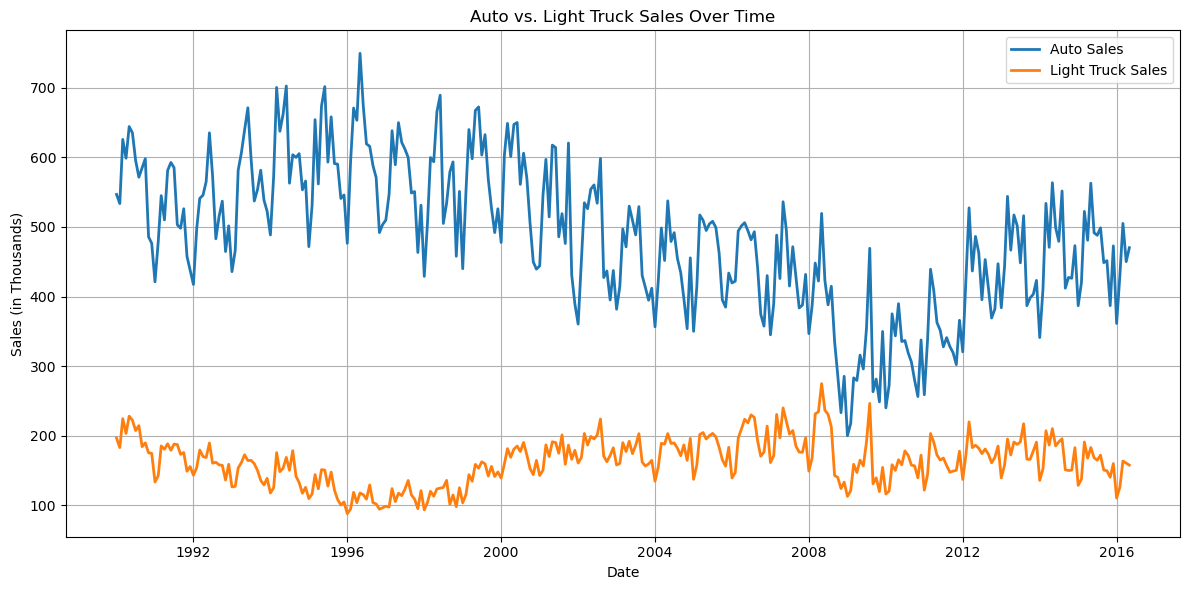

In [26]:
#Highlights seasonal patterns, unadjusted version

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Auto Sales'], label='Auto Sales', linewidth=2)
plt.plot(df['Date'], df['Light Truck Sales'], label='Light Truck Sales', linewidth=2)

plt.title('Auto vs. Light Truck Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales (in Thousands)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Data Cleaning:

Renamed messy column headers to meaningful names (Month, Year, Auto Sales, Light Truck Sales).

Fixed the Month column, converting it from mixed floats/NaNs into proper integer month values.

Dropped rows with missing Month values to prevent invalid dates.

Dropped rows with missing Auto or Light Truck Sales to avoid plotting gaps or false zeros.

Rebuilt a proper Date column using Year + Month to create a clean time‑series index.

Reordered columns to keep the dataset tidy and analysis‑ready.

Graph Shows: 

Auto sales (blue line) start out much higher in the early 1990s. Sedans dominated the market back then.

Light truck sales (orange line) begin lower but steadily climb over time. “Light trucks” include SUVs, crossovers, and pickups.

The lines cross in the mid‑2000s, meaning light trucks officially became more popular than traditional cars.

After the crossover, light truck sales stay consistently higher, reflecting the long‑term shift toward SUVs and pickups.

Both series show a sharp drop around 2008–2009, which lines up with the Great Recession.

Takeaway: Consumers moved away from cars and toward SUVs and trucks, and that shift has persisted.

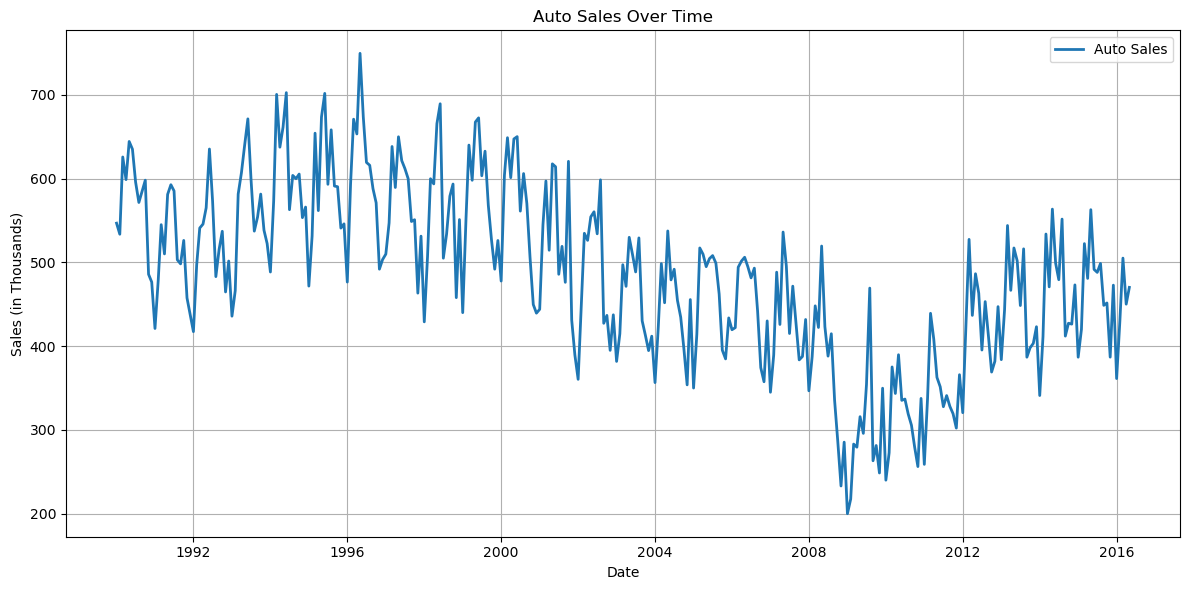

In [29]:
auto_only=df[['Date','Auto Sales']]

plt.figure(figsize=(12,6))

plt.plot(auto_only['Date'], auto_only['Auto Sales'], label='Auto Sales', linewidth=2)

plt.title('Auto Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales (in Thousands)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [68]:
cols_to_fix = [
    'Auto Sales', 'Light Truck Sales', 'auto_year_to_year_change',
    'Auto_SA', 'Truck_SA', 'Auto_SA_Change'
]

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')


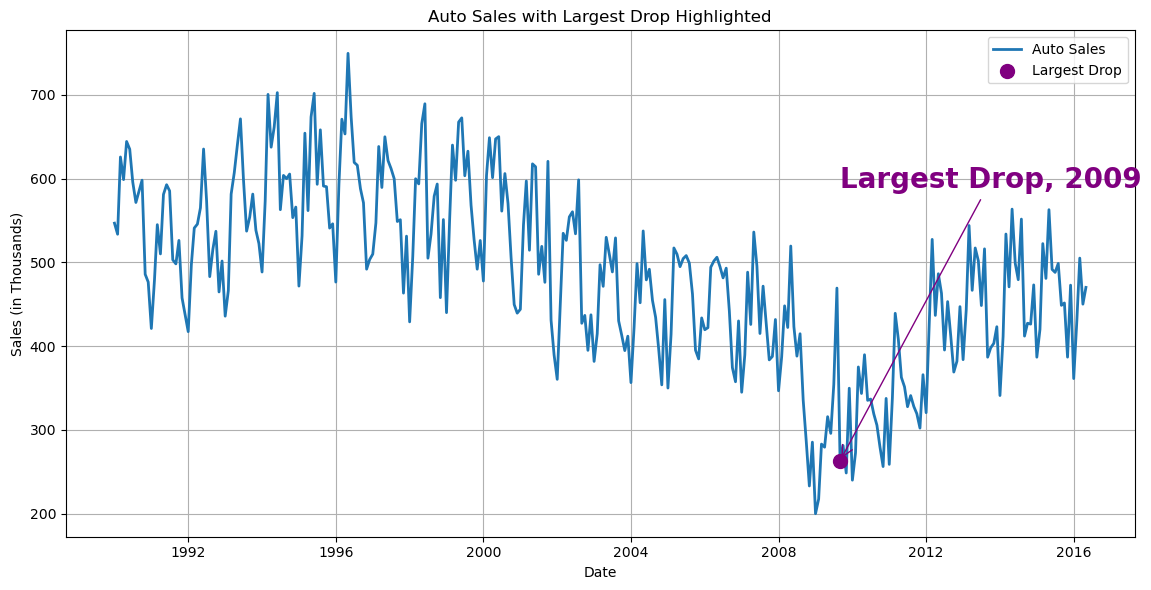

In [69]:
df['auto_year_to_year_change']=df['Auto Sales'].diff()
drop_idx=df['auto_year_to_year_change'].idxmin()
drop_date=df.loc[drop_idx, 'Date']
drop_value=df.loc[drop_idx, 'Auto Sales']

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Auto Sales'], label='Auto Sales', linewidth=2)

plt.scatter(drop_date, drop_value, color='purple', s=100, zorder=5, label='Largest Drop')

plt.annotate(
    "Largest Drop, 2009",
    xy=(drop_date, drop_value),
    xytext=(drop_date, drop_value + 325),
    arrowprops=dict(arrowstyle="->", color='purple'),
    fontsize=20,
    color='purple',
    fontweight='bold'
)

plt.title('Auto Sales with Largest Drop Highlighted')
plt.xlabel('Date')
plt.ylabel('Sales (in Thousands)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [70]:
largest_drop=df.loc[df['auto_year_to_year_change'].idxmin()]
largest_drop

year_of_drop=largest_drop['Year']
year_of_drop


np.float64(2009.0)

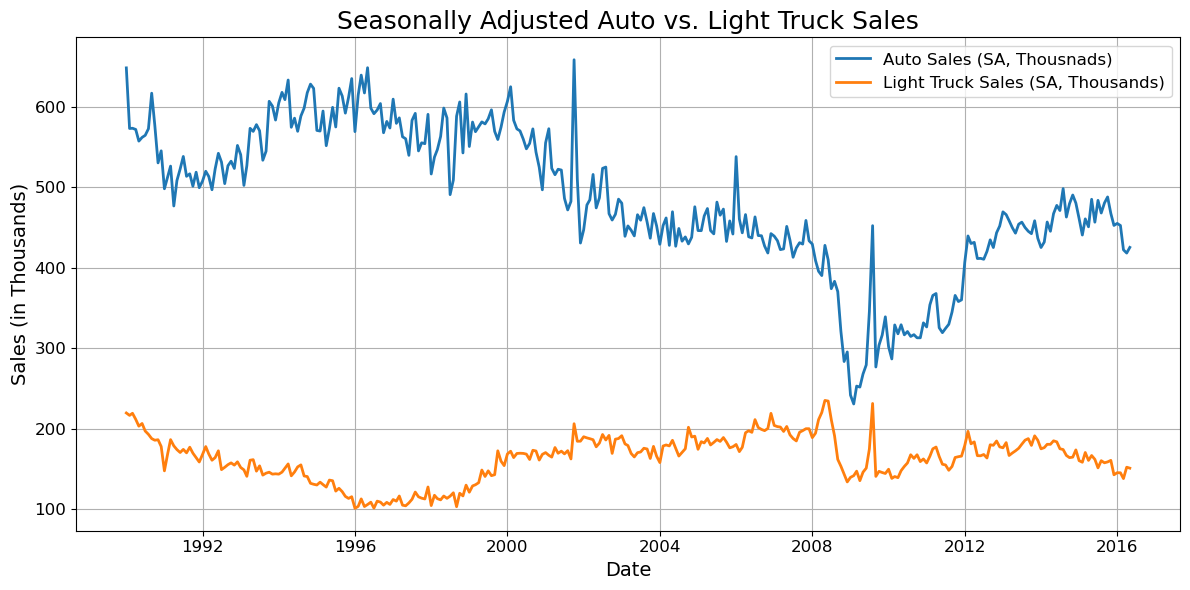

In [71]:
#analyze economic trends, using seasonally adjusted version
df_original=pd.read_excel("BEA Auto-Light Truck Sales.xlsx")
df['Auto_SA']=df_original['Unnamed: 4']
df['Truck_SA']=df_original['Unnamed: 9']

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Auto_SA'], label='Auto Sales (SA, Thousnads)', linewidth=2)
plt.plot(df['Date'], df['Truck_SA'], label='Light Truck Sales (SA, Thousands)', linewidth=2)

plt.title('Seasonally Adjusted Auto vs. Light Truck Sales', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales (in Thousands)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Auto drop value: -175.8
Before: 452.5
After: 276.7
Drop: -175.8
Before: 452.5
After: 276.7
Drop: -175.8


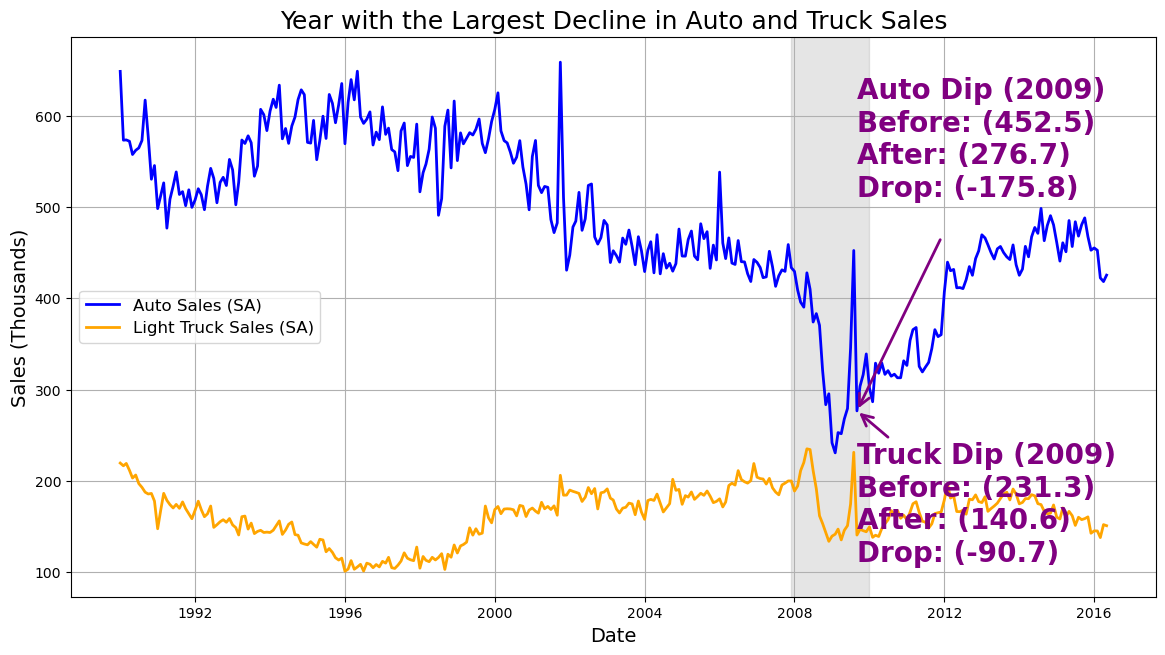

In [99]:
df['Auto_SA_Change']=df['Auto_SA'].diff()
dip_idx=df['Auto_SA_Change'].idxmin()
dip_date=df.loc[dip_idx, 'Date']
dip_year=dip_date.year
dip_value=df.loc[dip_idx, "Auto_SA"]

truck_idx=df['Truck_SA'].idxmin()
truck_date=df.loc[truck_idx, 'Date']
truck_value=df.loc[truck_idx, 'Truck_SA']

df=df.dropna(subset=['Auto_SA','Truck_SA'])

df['Auto_SA_Change']= df['Auto_SA'].diff()
dip1_idx=df['Auto_SA_Change'].idxmin()
auto_drop_value=df.loc[dip1_idx, 'Auto_SA_Change']


#print("Year of the largest auto dip:", dip_year)
#print("Year of the largest truck dip:", truck_date.year)
print('Auto drop value:', auto_drop_value)

auto_before=df.loc[dip_idx-1, 'Auto_SA']
auto_after=df.loc[dip_idx, 'Auto_SA']
auto_drop_value=after_value-before_value

print('Before:', before_value)
print('After:', after_value)
print('Drop:', auto_drop_value)

truck_before=df.loc[dip_idx-1, 'Truck_SA']
truck_after=df.loc[dip_idx, 'Truck_SA']
truck_drop_value=truck_after-truck_before

print('Before:', before_value)
print('After:', after_value)
print('Drop:', auto_drop_value)

plt.figure(figsize=(14,7))

plt.plot(df['Date'], df['Auto_SA'], label='Auto Sales (SA)', linewidth=2, color='blue')
plt.plot(df['Date'], df['Truck_SA'], label='Light Truck Sales (SA)', linewidth=2, color='orange')

#plt.scatter(dip_date, dip_value, color='purple', s=150, zorder=5)

#plt.annotate(
 #   f"Largest Auto Dip ({dip_date.year})",
  #  xy=(dip_date, dip_value),
   # xytext=(dip_date, dip_value + 80),   # move label upward
    #arrowprops=dict(arrowstyle="->", color="purple", linewidth=2),
    #fontsize=20,
    #fontweight="bold",
    #color="purple"
#)

#plt.scatter(dip_date, dip_value, color='purple', s=150, zorder=5)
#plt.annotate(
 #   f"Largest Truck Dip ({truck_date.year})",
  #  xy=(truck_date, truck_value),
   # xytext=(truck_date, truck_value + 80),   # move label upward
    #arrowprops=dict(arrowstyle="->", color="purple", linewidth=2),
    #fontsize=20,
    #fontweight="bold",
    #color="purple"
#)

plt.annotate(
    f"Auto Dip ({dip_date.year})\n"
    f"Before: ({auto_before:.1f})\n"
    f"After: ({auto_after:.1f})\n"
    f"Drop: ({auto_drop_value:.1f})\n",
    xy=(dip_date, dip_value),
    xytext=(dip_date, dip_value + 200),   # move label upward
    arrowprops=dict(arrowstyle="->", color="purple", linewidth=2),
    fontsize=20,
    fontweight="bold",
    color="purple"
)

plt.annotate(
    f"Truck Dip ({dip_date.year})\n"
    f"Before: ({truck_before:.1f})\n"
    f"After: ({truck_after:.1f})\n"
    f"Drop: ({truck_drop_value:.1f})\n",
    xy=(dip_date, dip_value),
    xytext=(dip_date, dip_value - 200),   # move label upward
    arrowprops=dict(arrowstyle="->", color="purple", linewidth=2),
    fontsize=20,
    fontweight="bold",
    color="purple"
)
plt.axvspan(pd.Timestamp("2007-12-01"), pd.Timestamp("2009-12-31"),
            color='gray', alpha=0.2)

plt.title('Year with the Largest Decline in Auto and Truck Sales', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales (Thousands)', fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

# Give the annotation room
plt.subplots_adjust(top=0.92, bottom=0.12)

plt.show()



In [ ]:
What the Auto Sales Trend (Seasonally Adjusted) Conveys
The long‑term trajectory of passenger car demand, showing how consumer interest in traditional cars has evolved over time.

The timing and severity of the largest decline in car sales, highlighted by your annotation so the audience can immediately see when the downturn occurred.

How economic cycles, fuel prices, and broader market conditions influence car purchases, reflected in the peaks and troughs of the line.

The reduced volatility after seasonal adjustment, making it easier to interpret underlying trends without holiday or calendar distortions.

A clear narrative of structural change in the auto market, where passenger car sales have generally weakened over the years.

A visual anchor point for discussion, since the annotated dip draws attention to a specific moment that may align with a recession, supply shock, or policy change.

In [73]:
def integrity_check(df): 
    print("Missing values:") 
    print(df.isna().sum()) 
    print("\nDuplicated rows:", df.duplicated().sum()) 
    print("\nData types:") 
    print(df.dtypes) 
    print("\nNegative values in Auto_SA or Truck_SA:") 
    print(df[(df['Auto_SA'] < 0) | (df['Truck_SA'] < 0)]) 
    print("\nDate monotonic:", df['Date'].is_monotonic_increasing) 

integrity_check(df)

Missing values:
Year                        0
Month                       0
Date                        0
Auto Sales                  0
Light Truck Sales           0
auto_year_to_year_change    1
Auto_SA                     0
Truck_SA                    0
Auto_SA_Change              1
dtype: int64

Duplicated rows: 0

Data types:
Year                               float64
Month                                int64
Date                        datetime64[ns]
Auto Sales                         float64
Light Truck Sales                  float64
auto_year_to_year_change           float64
Auto_SA                             object
Truck_SA                            object
Auto_SA_Change                      object
dtype: object

Negative values in Auto_SA or Truck_SA:
Empty DataFrame
Columns: [Year, Month, Date, Auto Sales, Light Truck Sales, auto_year_to_year_change, Auto_SA, Truck_SA, Auto_SA_Change]
Index: []

Date monotonic: True
